#### 1. Vad är klustring för något? Ge några exempel på tillämpningsområden.
Klustring är unsupervised learning där man grupperar observationer som liknar varandra, utan facit. Skillnaden mot klassificering är att grupperna inte är definierade i förväg. Exempel: kundsegmentering, marknadsanalys, anomalidetektering, dokumentgruppering.

#### 2. Förklara översiktligt hur K-means fungerar. Använd figur 6.3 (sidan 238) och figur 6.4 (sidan 239) i din förklaring.
K-means delar in datan i k kluster. Algoritmen placerar k centroider, tilldelar varje punkt till närmaste centroid, flyttar centroiderna till gruppens medelvärde, och upprepar tills de slutar röra sig. Figur 6.3 visar de sanna klustren i fyra dataset och figur 6.4 vad K-means faktiskt ger. Metoden fungerar bra på runda, jämnstora och väl åtskilda kluster, men misslyckas när man angett fel k, när klustren är avlånga istället för sfäriska, när spridningen skiljer sig mellan kluster, och när klustren är olika stora.

#### 3. Hur kan man välja vilket antal kluster som ska användas för en K-means modell? Använd inertia, silhouette score och silhouette diagram i ditt svar.
Inertia är summan av kvadrerade avstånd till centroiderna. Den sjunker alltid när k ökar, så man letar efter armbågen där kurvan planar ut. Silhouette score mäter hur nära en punkt ligger sitt eget kluster jämfört med närmaste grannkluster, går från −1 till 1, och har ett meningsfullt maximum. Silhouette-diagram visar varje punkts värde grupperat per kluster, vilket också avslöjar om klustren är olika stora eller innehåller felplacerade punkter.

#### 4. Om du kollar på figur 6.10 på sidan 247, hur många kluster hade du valt och varför? Är det en “exakt vetenskap” att välja antalet kluster?
I figur 6.10 faller inertia brant fram till k = 4 och planar sedan ut, så jag hade valt fyra kluster. Det är ingen exakt vetenskap — armbågen är sällan tydlig i verklig data, inertia och silhouette score pekar ofta åt olika håll, och vad resultatet ska användas till väger ofta tyngre än måtten.

#### 5. Hur tolkar man figur 6.13 på sidan 251?
Figur 6.13 visar silhouette-diagram för k mellan 3 och 6. Varje kniv är ett kluster: tjockleken visar antalet punkter och längden hur höga silhouettevärdena är. Den röda linjen är genomsnittet. Vid k = 3 och k = 4 är scoren hög men ett kluster är mycket större än de andra. Vid k = 5 är scoren något lägre men klustren jämnstora och alla når förbi linjen. Vid k = 6 sjunker scoren och alla knivar når inte fram. Fem kluster är därför ett rimligt val trots att scoren inte är högst där.

#### 7. Klustring av kaliforniska distrikt

   median_income  latitude  longitude
0         8.3252     37.88    -122.23
1         8.3014     37.86    -122.22
2         7.2574     37.85    -122.24
3         5.6431     37.85    -122.25
4         3.8462     37.85    -122.25


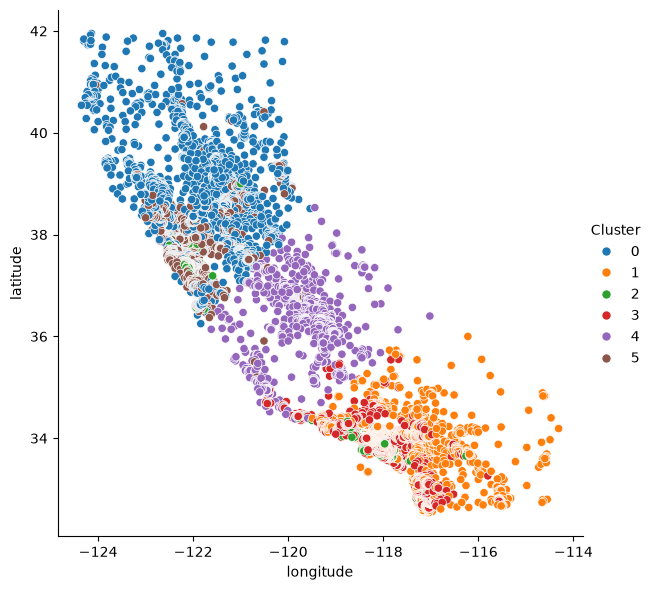

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

df = pd.read_csv("../data/housing.csv")
X = df.loc[:, ["median_income", "latitude", "longitude"]]
print(X.head())

kmeans = KMeans(n_clusters=6, n_init=10, random_state=42)
X["Cluster"] = kmeans.fit_predict(X)
X["Cluster"] = X["Cluster"].astype("category")

sns.relplot(x="longitude", y="latitude", hue="Cluster", data=X, height=6)
plt.show()

#### a) Vad koden gör
Datan läses in och tre variabler väljs: median_income, latitude och longitude. 
KMeans med n_clusters=6 delar in de 20 640 distrikten i sex grupper genom att 
upprepade gånger tilldela varje distrikt till närmaste klustercentrum och sedan 
flytta centrumen till gruppens medelvärde.

fit_predict() gör två saker i ett anrop: tränar modellen och returnerar 
klustertillhörigheten för varje rad. Resultatet läggs i en ny kolumn Cluster, 
som konverteras till category så att seaborn färgsätter den som diskreta 
grupper istället för en kontinuerlig skala.

Plotten ritar distrikten på deras geografiska koordinater, färgade efter kluster. 
Kartan över Kalifornien framträder eftersom latitude och longitude används.

Två tillägg till bokens kod: n_init=10 kör algoritmen tio gånger med olika 
startpunkter och behåller den bästa, och random_state=42 gör resultatet 
reproducerbart. Utan dem kan klusternumren och indelningen ändras mellan körningar.

Notera att koden inte skalar variablerna. Här är det mindre allvarligt än vanligt, 
eftersom de tre variablernas standardavvikelser råkar ligga nära varandra 
(1,9 för inkomst, 2,1 för latitud, 2,0 för longitud), men som princip bör data 
skalas före K-means.

In [2]:
# Vad kännetecknar varje kluster?
X.groupby("Cluster", observed=True).mean().round(2)

,median_income,latitude,longitude
Cluster,,,
0,2.81,38.35,-121.89
1,2.87,33.82,-117.83
2,10.95,35.01,-119.35
3,5.52,33.86,-118.03
4,2.67,36.10,-119.73
5,5.50,37.71,-121.97


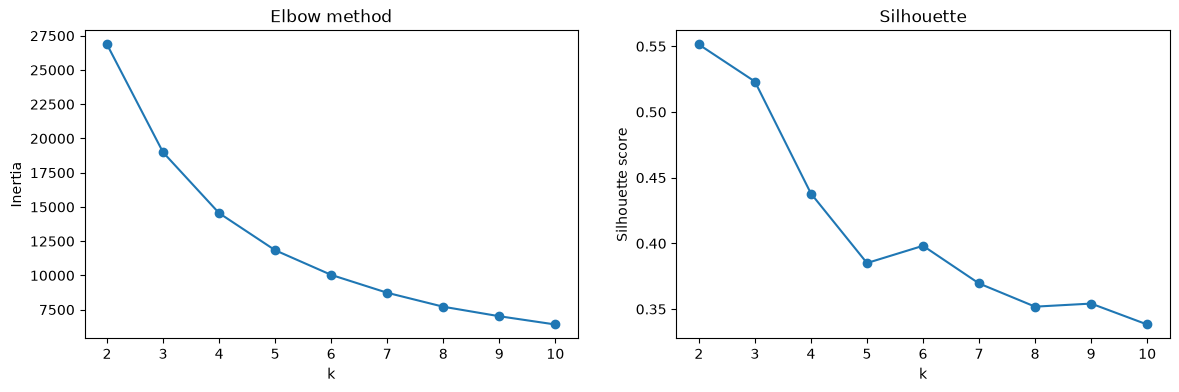

In [3]:
#d) Hur många kluster vore lämpligt?
X_scaled = StandardScaler().fit_transform(df[["median_income", "latitude", "longitude"]])

inertias, silhouettes = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_,
                                        sample_size=5000, random_state=42))

fig, axs = plt.subplots(1, 2, figsize=(14, 4))
axs[0].plot(k_range, inertias, marker="o")
axs[0].set_xlabel("k"); axs[0].set_ylabel("Inertia"); axs[0].set_title("Elbow method")
axs[1].plot(k_range, silhouettes, marker="o")
axs[1].set_xlabel("k"); axs[1].set_ylabel("Silhouette score"); axs[1].set_title("Silhouette")
plt.show()

**b) Vilken information hade jag velat ha om varje kluster?**

Klustren är geografiska grupper med olika inkomstnivå. För en marknadsundersökning 
skulle jag vilja veta:

- **Demografi** — hushållsstorlek, åldersfördelning, familjesituation
- **Boende** — hustyp, ägd eller hyrd bostad, planer på att flytta
- **Kontaktpreferenser** — mejl, telefon, sociala medier, fysisk post
- **Medievanor** — var de söker information om bostäder
- **Prioriteringar vid bostadsköp** — pris, skolor, pendlingsavstånd, trygghet
- **Betalningsvilja** och känslighet för ränteförändringar

**Design av undersökningen:** stratifierat urval med ett bestämt antal svarande 
per kluster, så att även det minsta klustret (459 distrikt) blir representerat. 
Webbenkät som grund, kompletterad med djupintervjuer i några kluster för att 
förstå motiven bakom svaren. Samma frågeformulär till alla, så att grupperna kan 
jämföras. Antal svarande sätts så att skillnader mellan kluster kan säkerställas 
statistiskt.

**c) Hur kan detta användas?**

- **Riktad marknadsföring** — annonser anpassade efter varje klusters preferenser 
  och kanaler, istället för samma budskap till alla
- **Etableringsbeslut** — var nya kontor eller butiker bör öppnas
- **Produktanpassning** — olika bolåneprodukter för hög- och låginkomstområden
- **Prissättning** per område
- **Resursfördelning** — var säljarna gör mest nytta

Värdet ligger i att gå från "kunder i Kalifornien" till sex hanterbara grupper 
med olika behov.

**d) Antal kluster**

Inertia-kurvan sjunker jämnt utan tydlig armbåge, vilket är vanligt i verkliga 
data. Silhouette score är högst vid k = 2 (0,55) och sjunker sedan, med en liten 
återhämtning vid k = 6 (0,40).

Rent matematiskt talar det för två kluster — troligen norra och södra Kalifornien. 
För marknadsföringsändamål är två grupper dock för trubbigt. Sex kluster ger en 
finare indelning som fortfarande är hanterbar, och det är ett rimligt val trots 
att silhouette score är lägre. Det illustrerar poängen i fråga 4: valet av k är 
ingen exakt vetenskap utan beror på vad resultatet ska användas till.

#### 9. Klustringanalys av 1980-talets hits

In [4]:
hits = pd.read_csv("../data/1980sClassics.csv")
print(hits.shape)
print(hits.columns.tolist())
hits.head()

(998, 17)
['Track', 'Artist', 'Duration', 'Time_Signature', 'Danceability', 'Energy', 'Key', 'Loudness', 'Mode', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Popularity', 'Year']


,Track,Artist,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,Year
0,Babe,Styx,3:38,4,0.700,0.582,11,-5.960,0,0.0356,0.05020,0.000000,0.0881,0.785,116.712,96,1980
1,The Rose,Bette Midler,4:04,4,0.264,0.640,8,-6.221,1,0.0442,0.03930,0.000002,0.1510,0.190,84.828,92,1980
2,Cars,Gary Numan,4:08,4,0.338,0.562,9,-7.181,1,0.0290,0.03900,0.000000,0.1070,0.259,149.907,82,1980
3,Magic,Olivia Newton-John,2:17,4,0.911,0.689,1,-6.176,1,0.2650,0.00119,0.000000,0.0704,0.546,140.034,80,1980
4,We Don’t Talk Anymore,Cliff Richard,3:37,4,0.728,0.563,1,-8.053,0,0.1340,0.62100,0.000000,0.1790,0.352,100.017,80,1980


In [5]:
print(hits.isna().sum().sum(), "saknade värden")

# Duration är text i formatet "3:38" — görs om till sekunder
hits["Duration_sec"] = hits["Duration"].str.split(":").apply(
    lambda p: int(p[0]) * 60 + int(p[1]))

features = ["Danceability", "Energy", "Loudness", "Speechiness", "Acousticness",
            "Instrumentalness", "Liveness", "Valence", "Tempo", "Duration_sec"]

X = hits[features]
X_scaled = StandardScaler().fit_transform(X)
print(X.shape)

0 saknade värden
(998, 10)


998 låtar utan saknade värden. Duration låg som text ("3:38") och räknades om 
till sekunder.

Tio ljudegenskaper används. Key, Mode och Time_Signature utesluts trots att de 
är numeriska — Key är tonart (0–11) och Mode är dur eller moll, alltså 
kategoriska värden där avstånd inte betyder något. Popularity och Year utesluts 
eftersom de beskriver låtens mottagande och årtal, inte hur den låter.

Variablerna skalas, eftersom K-means bygger på avstånd och Tempo (cirka 120) 
annars skulle dominera helt över Danceability (mellan 0 och 1).

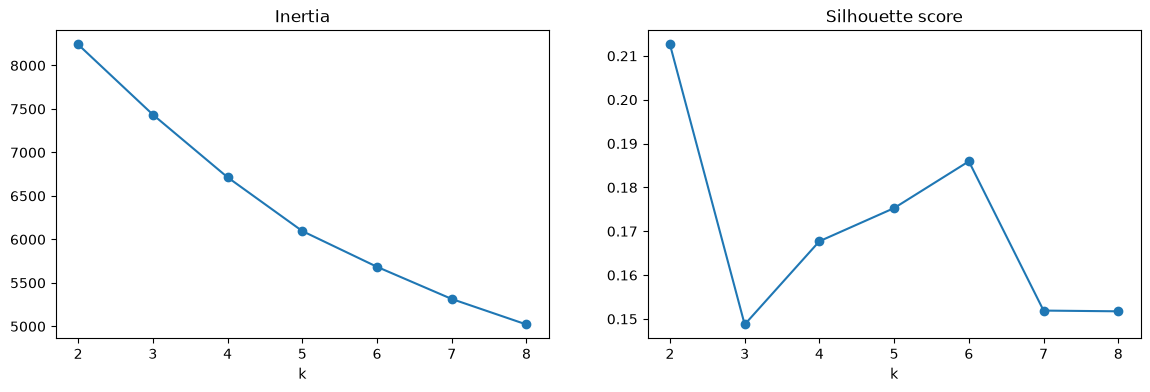

In [6]:
inertias, silhouettes = [], []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axs = plt.subplots(1, 2, figsize=(14, 4))
axs[0].plot(k_range, inertias, marker="o")
axs[0].set_xlabel("k"); axs[0].set_title("Inertia")
axs[1].plot(k_range, silhouettes, marker="o")
axs[1].set_xlabel("k"); axs[1].set_title("Silhouette score")
plt.show()

In [7]:
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
hits["Cluster"] = kmeans.fit_predict(X_scaled)

print(hits["Cluster"].value_counts().sort_index())
hits.groupby("Cluster")[features].mean().round(2)

Cluster
0    289
1    421
2     32
3    256
Name: count, dtype: int64


,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_sec
Cluster,,,,,,,,,,
0,0.56,0.78,-6.00,0.09,0.13,0.01,0.28,0.58,130.94,222.15
1,0.73,0.68,-9.06,0.05,0.15,0.02,0.12,0.79,116.10,254.81
2,0.61,0.46,-13.22,0.06,0.50,0.81,0.13,0.40,130.95,198.59
3,0.53,0.41,-11.32,0.04,0.50,0.01,0.16,0.36,116.22,241.36


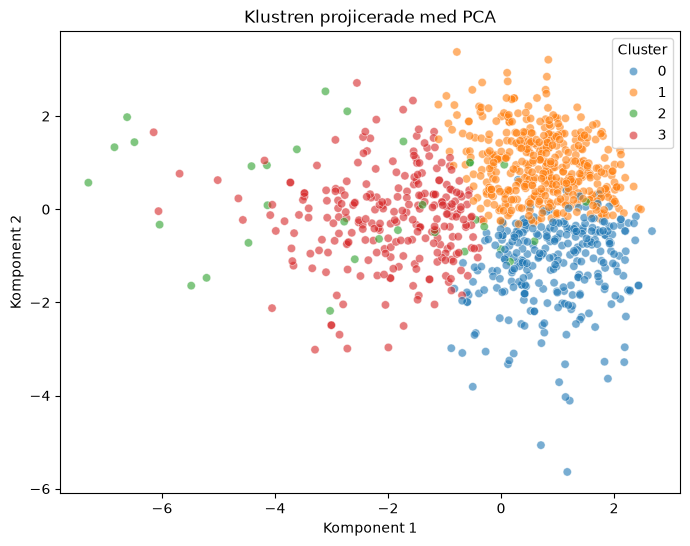

In [8]:
coords = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=hits["Cluster"],
                palette="tab10", alpha=0.6)
plt.xlabel("Komponent 1"); plt.ylabel("Komponent 2")
plt.title("Klustren projicerade med PCA")
plt.show()

In [9]:
for c in sorted(hits["Cluster"].unique()):
    print(f"\nKluster {c} ({(hits['Cluster'] == c).sum()} låtar):")
    print(hits[hits["Cluster"] == c][["Track", "Artist"]].head(5).to_string(index=False))


Kluster 0 (289 låtar):
    Track             Artist
 The Rose       Bette Midler
     Cars         Gary Numan
    Magic Olivia Newton-John
   Desire          Andy Gibb
Real Love    Doobie Brothers

Kluster 1 (421 låtar):
                        Track          Artist
                         Babe            Styx
                Rock With You Michael Jackson
                  Upside Down      Diana Ross
Escape (THE Piña Colada Song)   Rupert Holmes
                        Still      Commodores

Kluster 2 (32 låtar):
                            Track                    Artist
                        Funkytown                 Lipps Inc
                Let’s Get Serious          Jermaine Jackson
Don’t Fall In Love With A Dreamer Kenny Rogers & Kim Carnes
  You’re The Only Woman (YOU & I)                  Ambrosia
                          Rapture                   Blondie

Kluster 3 (256 låtar):
                Track                   Artist
We Don’t Talk Anymore            Cliff Richard
 

**Resultat med fyra kluster**

- **Kluster 0 (289 låtar)** — hög energy (0,78) och högst liveness (0,28), 
  snabbast tempo. Rockigare låtar med livekänsla.
- **Kluster 1 (421 låtar)** — högst danceability (0,73) och valence (0,79), 
  alltså glada och dansanta poplåtar. Det största klustret.
- **Kluster 2 (32 låtar)** — instrumentalness 0,81 mot 0,01–0,02 i övriga. 
  Instrumentala eller nästan sånglösa spår. Litet men mycket tydligt kluster.
- **Kluster 3 (256 låtar)** — låg energy (0,41), låg valence (0,36) och hög 
  acousticness (0,50). Lugna, melankoliska ballader.

**Om antalet kluster:** silhouette score är låg genomgående (0,15–0,21) och 
högst vid k = 2. Inertia-kurvan faller jämnt utan tydlig armbåge. Det betyder 
att låtarna inte delar upp sig i naturligt åtskilda grupper — de ligger snarare 
på ett kontinuum av ljudegenskaper, och K-means drar godtyckliga gränser genom 
molnet. PCA-plotten visar samma sak: klustren ligger bredvid varandra utan 
tydliga mellanrum.

Fyra kluster valdes ändå eftersom grupperna går att beskriva i ord och är 
någorlunda jämnstora, vilket är mer användbart än två. Det illustrerar poängen 
från fråga 4: valet av k är ingen exakt vetenskap, och verksamhetsnyttan väger 
tyngre än måtten.

**Användning:** automatisk generering av spellistor efter stämningsläge, 
rekommendationer baserade på hur låtar faktiskt låter snarare än genre-etiketter, 
eller underlag för radioprogrammering där man vill variera mellan lugna och 
energiska partier.